In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the CSV file inside the dataset
file_path = "diabetes_prediction_dataset.csv"

# Load the latest version into a pandas DataFrame
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "iammustafatz/diabetes-prediction-dataset",
  file_path,
)

print("First 5 records:", df.head())

/tmp/ipykernel_801/2662165820.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'diabetes-prediction-dataset' dataset.
First 5 records:    gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


DIABETES PREDICTION USING SVM
CLASSICAL MACHINE LEARNING

Loading dataset...
Using Colab cache for faster access to the 'diabetes-prediction-dataset' dataset.
Dataset loaded successfully!

DATASET INFORMATION

Dataset Shape:
(100000, 9)

First 5 Records:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  

Column Names:
['gender', 'age

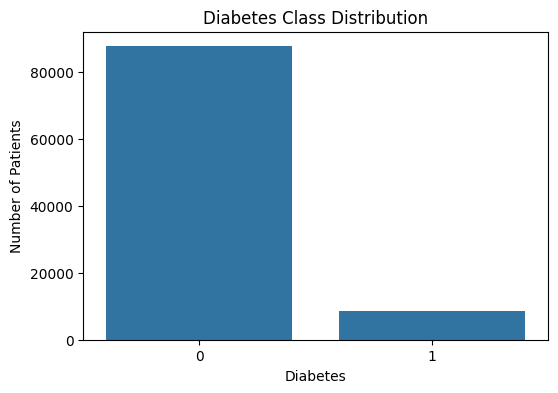

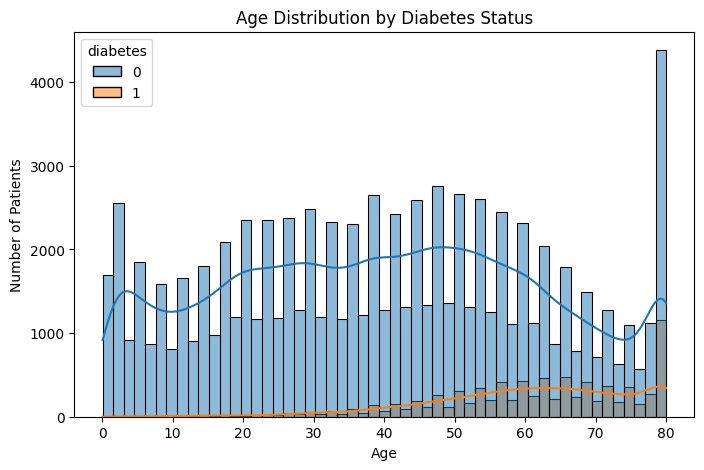

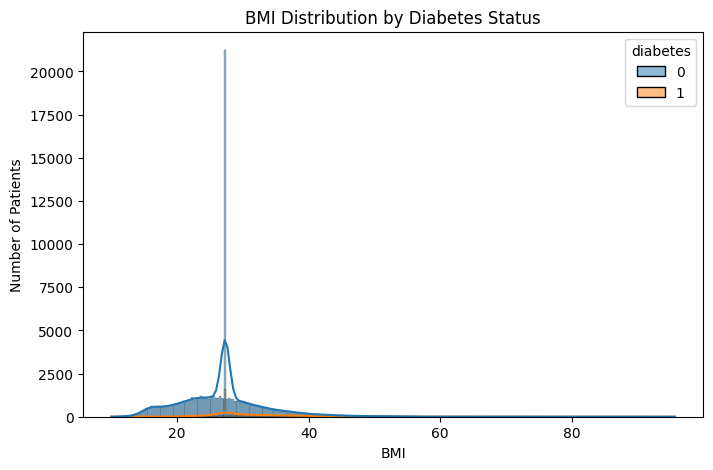

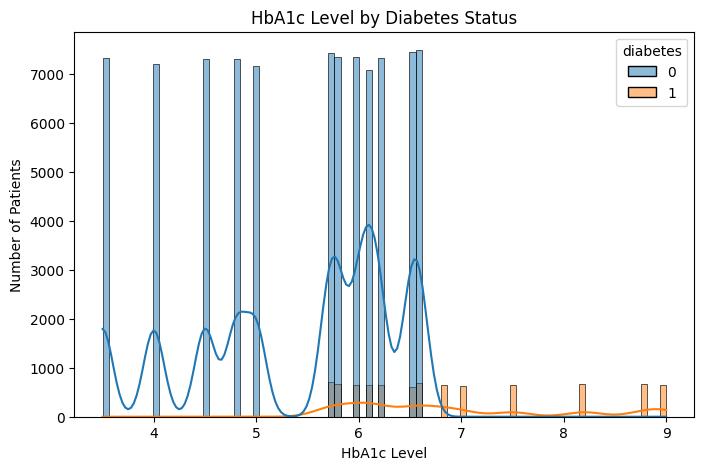

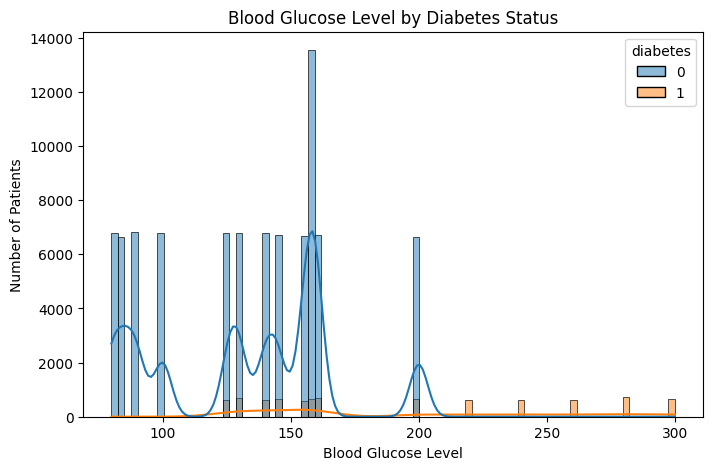

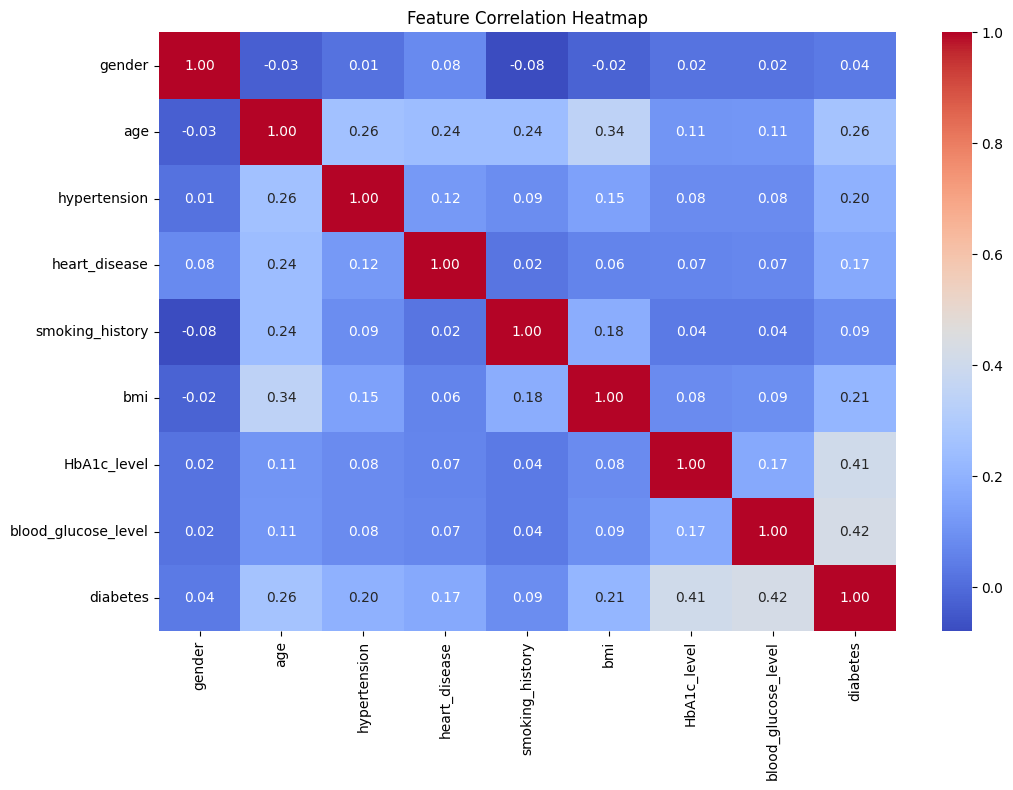


Features:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']

Target:
diabetes

Categorical Features:
['gender', 'smoking_history']

Numerical Features:
['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']

TRAIN / TEST SPLIT
Training samples: 76916
Testing samples : 19230

CREATING SVM MODEL

Training SVM model...
SVM training completed successfully!

SVM MODEL PERFORMANCE

Accuracy  : 0.8834
Precision : 0.4252
Recall    : 0.9151
F1 Score  : 0.5806
ROC-AUC   : 0.9643

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 No Diabetes       0.99      0.88      0.93     17534
    Diabetes       0.43      0.92      0.58      1696

    accuracy                           0.88     19230
   macro avg       0.71      0.90      0.76     19230
weighted avg       0.94      0.88      0.90     19230



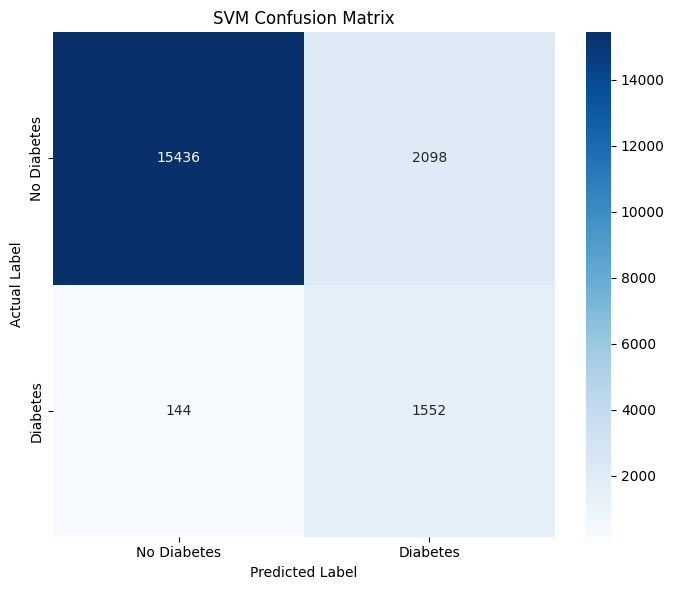

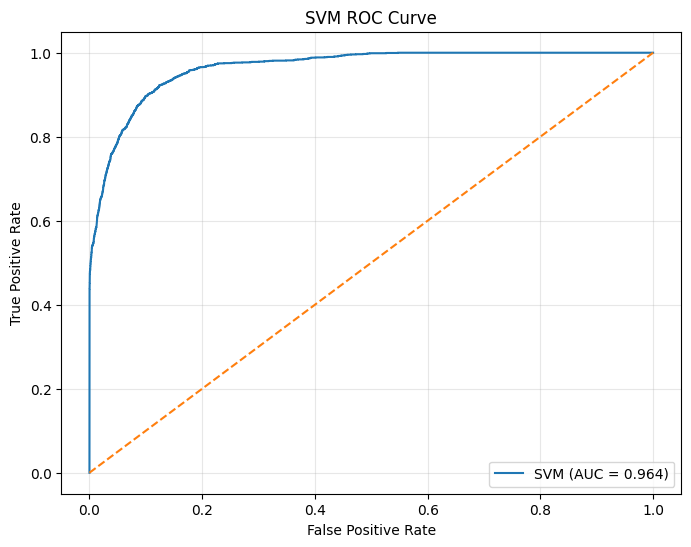


5-FOLD CROSS VALIDATION


In [ ]:
# ================================================================
# DIABETES PREDICTION USING SVM
# CLASSICAL MACHINE LEARNING - GOOGLE COLAB
# ================================================================

# ------------------------------------------------
# 1. INSTALL REQUIRED LIBRARIES
# ------------------------------------------------

!pip install -q kagglehub[pandas-datasets] joblib


# ------------------------------------------------
# 2. IMPORT LIBRARIES
# ------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

warnings.filterwarnings("ignore")

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


print("=" * 70)
print("DIABETES PREDICTION USING SVM")
print("CLASSICAL MACHINE LEARNING")
print("=" * 70)


# ------------------------------------------------
# 3. LOAD DATASET FROM KAGGLE
# ------------------------------------------------

print("\nLoading dataset...")

file_path = "diabetes_prediction_dataset.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "iammustafatz/diabetes-prediction-dataset",
    file_path,
)

print("Dataset loaded successfully!")


# ------------------------------------------------
# 4. DATASET INFORMATION
# ------------------------------------------------

print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Records:")
print(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)


# ------------------------------------------------
# 5. MISSING VALUE CHECK
# ------------------------------------------------

print("\n" + "=" * 70)
print("MISSING VALUE CHECK")
print("=" * 70)

print(df.isnull().sum())

if df.isnull().sum().sum() == 0:
    print("\nNo missing values found.")
else:
    print("\nMissing values found. Removing rows...")
    df = df.dropna().reset_index(drop=True)


# ------------------------------------------------
# 6. DUPLICATE CHECK
# ------------------------------------------------

print("\n" + "=" * 70)
print("DUPLICATE CHECK")
print("=" * 70)

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")

print("Final dataset shape:", df.shape)


# ------------------------------------------------
# 7. TARGET DISTRIBUTION
# ------------------------------------------------

print("\n" + "=" * 70)
print("TARGET DISTRIBUTION")
print("=" * 70)

print("\nNumber of samples in each class:")
print(df["diabetes"].value_counts())

print("\nPercentage of each class:")
print(
    df["diabetes"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# ------------------------------------------------
# 8. TARGET VISUALIZATION
# ------------------------------------------------

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="diabetes"
)

plt.title("Diabetes Class Distribution")
plt.xlabel("Diabetes")
plt.ylabel("Number of Patients")

plt.show()


# ------------------------------------------------
# 9. BASIC EDA
# ------------------------------------------------

# Age distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    hue="diabetes",
    kde=True
)

plt.title("Age Distribution by Diabetes Status")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()


# BMI distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="bmi",
    hue="diabetes",
    kde=True
)

plt.title("BMI Distribution by Diabetes Status")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")

plt.show()


# HbA1c distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="HbA1c_level",
    hue="diabetes",
    kde=True
)

plt.title("HbA1c Level by Diabetes Status")
plt.xlabel("HbA1c Level")
plt.ylabel("Number of Patients")

plt.show()


# Blood glucose distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="blood_glucose_level",
    hue="diabetes",
    kde=True
)

plt.title("Blood Glucose Level by Diabetes Status")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Number of Patients")

plt.show()


# ------------------------------------------------
# 10. CORRELATION HEATMAP
# ------------------------------------------------

correlation_df = df.copy()

# Temporary encoding for visualization only

correlation_df["gender"] = (
    correlation_df["gender"]
    .astype("category")
    .cat.codes
)

correlation_df["smoking_history"] = (
    correlation_df["smoking_history"]
    .astype("category")
    .cat.codes
)

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.show()


# ------------------------------------------------
# 11. SEPARATE FEATURES AND TARGET
# ------------------------------------------------

X = df.drop(
    "diabetes",
    axis=1
)

y = df["diabetes"]

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("diabetes")


# ------------------------------------------------
# 12. DEFINE FEATURE TYPES
# ------------------------------------------------

categorical_features = [
    "gender",
    "smoking_history"
]

numerical_features = [
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

print("\nCategorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)


# ------------------------------------------------
# 13. TRAIN / TEST SPLIT
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


# ------------------------------------------------
# 14. PREPROCESSING
# ------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[

        # Numerical features
        (
            "num",
            StandardScaler(),
            numerical_features
        ),

        # Categorical features
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)


# ------------------------------------------------
# 15. SVM MODEL
# ------------------------------------------------

print("\n" + "=" * 70)
print("CREATING SVM MODEL")
print("=" * 70)

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)


# ------------------------------------------------
# 16. CREATE PIPELINE
# ------------------------------------------------

svm_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "svm",
            svm_model
        )
    ]
)


# ------------------------------------------------
# 17. TRAIN SVM
# ------------------------------------------------

print("\nTraining SVM model...")

svm_pipeline.fit(
    X_train,
    y_train
)

print("SVM training completed successfully!")


# ------------------------------------------------
# 18. PREDICTION
# ------------------------------------------------

y_pred = svm_pipeline.predict(
    X_test
)

y_probability = svm_pipeline.predict_proba(
    X_test
)[:, 1]


# ------------------------------------------------
# 19. MODEL EVALUATION
# ------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)


print("\n" + "=" * 70)
print("SVM MODEL PERFORMANCE")
print("=" * 70)

print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")


# ------------------------------------------------
# 20. CLASSIFICATION REPORT
# ------------------------------------------------

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Diabetes",
            "Diabetes"
        ],
        zero_division=0
    )
)


# ------------------------------------------------
# 21. CONFUSION MATRIX
# ------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Diabetes",
        "Diabetes"
    ],
    yticklabels=[
        "No Diabetes",
        "Diabetes"
    ]
)

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.tight_layout()

plt.show()


# ------------------------------------------------
# 22. ROC CURVE
# ------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"SVM (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("SVM ROC Curve")

plt.legend()

plt.grid(alpha=0.3)

plt.show()


# ------------------------------------------------
# 23. 5-FOLD CROSS VALIDATION
# ------------------------------------------------

print("\n" + "=" * 70)
print("5-FOLD CROSS VALIDATION")
print("=" * 70)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    svm_pipeline,
    X,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("\nCross-validation ROC-AUC scores:")

for i, score in enumerate(
    cv_scores,
    start=1
):
    print(
        f"Fold {i}: {score:.4f}"
    )

print(
    f"\nMean ROC-AUC: {cv_scores.mean():.4f}"
)

print(
    f"Standard Deviation: {cv_scores.std():.4f}"
)


# ------------------------------------------------
# 24. PREDICTION FUNCTION
# ------------------------------------------------

def predict_diabetes(
    gender,
    age,
    hypertension,
    heart_disease,
    smoking_history,
    bmi,
    HbA1c_level,
    blood_glucose_level
):

    patient = pd.DataFrame({

        "gender": [gender],

        "age": [age],

        "hypertension": [hypertension],

        "heart_disease": [heart_disease],

        "smoking_history": [smoking_history],

        "bmi": [bmi],

        "HbA1c_level": [HbA1c_level],

        "blood_glucose_level": [
            blood_glucose_level
        ]
    })

    prediction = svm_pipeline.predict(
        patient
    )[0]

    probability = (
        svm_pipeline
        .predict_proba(patient)[0][1]
    )

    if prediction == 1:
        result = "Diabetes"
    else:
        result = "No Diabetes"

    return result, probability


# ------------------------------------------------
# 25. TEST PATIENT 1
# ------------------------------------------------

print("\n" + "=" * 70)
print("TEST PATIENT 1")
print("=" * 70)

result, probability = predict_diabetes(

    gender="Female",

    age=45,

    hypertension=1,

    heart_disease=0,

    smoking_history="never",

    bmi=28.4,

    HbA1c_level=6.2,

    blood_glucose_level=145
)

print("\nPrediction:", result)

print(
    f"Diabetes Probability: "
    f"{probability * 100:.2f}%"
)


# ------------------------------------------------
# 26. TEST PATIENT 2
# ------------------------------------------------

print("\n" + "=" * 70)
print("TEST PATIENT 2")
print("=" * 70)

result, probability = predict_diabetes(

    gender="Male",

    age=25,

    hypertension=0,

    heart_disease=0,

    smoking_history="never",

    bmi=22.5,

    HbA1c_level=5.2,

    blood_glucose_level=100
)

print("\nPrediction:", result)

print(
    f"Diabetes Probability: "
    f"{probability * 100:.2f}%"
)


# ------------------------------------------------
# 27. SAVE TRAINED MODEL
# ------------------------------------------------

print("\n" + "=" * 70)
print("SAVING SVM MODEL")
print("=" * 70)

model_filename = (
    "diabetes_svm_model.pkl"
)

joblib.dump(
    svm_pipeline,
    model_filename
)

print(
    "Model saved successfully:"
)

print(model_filename)

print(
    "File exists:",
    os.path.exists(model_filename)
)


# ------------------------------------------------
# 28. SAVE PERFORMANCE RESULTS
# ------------------------------------------------

performance = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "CV Mean ROC-AUC",
        "CV Std ROC-AUC"
    ],

    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        cv_scores.mean(),
        cv_scores.std()
    ]
})

performance.to_csv(
    "svm_performance_results.csv",
    index=False
)

print(
    "\nPerformance results saved as:"
)

print(
    "svm_performance_results.csv"
)


# ------------------------------------------------
# 29. FINAL SUMMARY
# ------------------------------------------------

print("\n" + "=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)

print(
    f"""
Algorithm       : Support Vector Machine (SVM)
Kernel          : RBF
Dataset Samples : {df.shape[0]}

Accuracy        : {accuracy:.4f}
Precision       : {precision:.4f}
Recall          : {recall:.4f}
F1 Score        : {f1:.4f}
ROC-AUC         : {roc_auc:.4f}

5-Fold CV Mean  : {cv_scores.mean():.4f}
5-Fold CV Std   : {cv_scores.std():.4f}

Model File:
{model_filename}

Performance File:
svm_performance_results.csv
"""
)

print("=" * 70)
print("SVM DIABETES PREDICTION COMPLETED")
print("=" * 70)